# Using Machine Learning to Determine Phenological State Along the Appalachian Trail in Massachusetts

Fall is one of the peak tourist seasons in the Berkshires, as visitors come to see the colorful leaves. Many people time their hikes along the Appalachian Trail around the timing of autumn foliage. This notebook develops models to predict the current phenological (i.e., seasonalal) state of forested pixels along the Appalachian Trail in Massachusetts. This code is run locally, but the best models are stored on GitHub to be used to update a web page on current predictions daily via GitHub Action.

This is a land cover change question, but rather than detecting changes between ecosystem types, these models classify where the canopy is within the seasonal greendown curve. Simpler approaches could be built from specific EVI or NDVI thresholds, the percent change relative to summer or winter values, or rates of change across recent observations. However, these methods are sensitive to noisy satellite data. Smoothing can reduce noise but makes it difficult to track the precise start and end of greendown in near-real time, and logistic greendown curves can only be fit robustly after the season has ended. The machine learning models developed here instead predict, from a snapshot of current and recent conditions, what stage of the greendown curve each pixel is currently experiencing.

This notebook trains and evaluates machine learning models to classify the fall phenological state of forested pixels along the Appalachian Trail in Massachusetts. Each pixel-day observation is assigned one of four labels — **before** (pre-greendown), **early** (early color change), **late** (peak to near-complete greendown), or **after** (post-greendown — based on its day-of-year relative to fitted logistic curve transition dates.

Satellite-derived vegetation indices (EVI and NDVI) from the Harmonized Landsat Sentinel-2 (HLS) dataset are used as input features, along with day length and recent temperature. Two model families are explored:

- **Decision trees** — fast and interpretable, trained on individual observations independently
- **Recurrent neural networks (LSTM)** — trained on temporal sequences of observations per pixel per year, able to exploit within-season context

Multiple variants of each model type are trained to evaluate regularization and training strategies. All models are compared on a held-out test set in the final section.

The best-performing models are deployed via GitHub Actions to generate daily predictions of phenological state within a 50 m buffer of the Appalachian Trail in Massachusetts. Predictions are available at https://k-wheeler.github.io/phenology/. Satellite and weather data are pulled from Google Earth Engine.

This project was developed by Kathryn Wheeler, Ph.D., with the assistance of Claude Code.

Below is a summary of the analysis decisions. The full analysis is at https://github.com/k-wheeler/AppTrail_Phenology.

In [12]:
%load_ext autoreload
%autoreload 2

# ── Load libraries and functions ──────────────────────────────────────────────
import os

import ee
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio.features
from pyproj import Transformer as ProjTransformer
from shapely.geometry import shape
from shapely.ops import transform as shapely_transform

from build_data_table import build_feature_table
from constants import DATA_DIR, GREENDOWN_DIR, MODEL_DIR
from decision_trees import split_data
from edit_data_table import edit_feature_table
from identify_locations import identify_route_buffer
from model_comparison import _dt_report, _rnn_report
from rnn_model import (
    build_rnn_sequences, compute_rnn_norm_stats, normalize_sequences,
    split_sequences, load_rnn_model
)

ee.Initialize(project='turnkey-lacing-391919')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
# ── Set spatial-temporal scope ────────────────────────────────────────────────
# 100m buffer for training/validation/test data — wider area gives more pixels
# and CI-width diversity for model training.
# Serving (generate_web_outputs.py) stays at the default 50m buffer.
route_buffer_50 = identify_route_buffer(buffer_m=50)

start_year = 2013  # First HLS year
train_year = 2024  # Last year included in model training

# ── Build and edit labeled feature table ──────────────────────────────────────
training_years = list(range(start_year, train_year + 1))
feature_df = build_feature_table(DATA_DIR, GREENDOWN_DIR, training_years)

feature_df_edited = edit_feature_table(feature_df, GREENDOWN_DIR, MODEL_DIR)

  2013: 1038 qualifying pixels
  2014: 361 qualifying pixels
  2015: 666 qualifying pixels
  2016: 493 qualifying pixels
  2017: 306 qualifying pixels
  2018: 1625 qualifying pixels
  2019: 255 qualifying pixels
  2020: 273 qualifying pixels
  2021: 685 qualifying pixels
  2022: 760 qualifying pixels
  2023: 843 qualifying pixels
  2024: 741 qualifying pixels

Total labeled phenology observations: 205486
  Dropped 16092 rows with NaN delta values (7.8% of rows)


In [14]:
# ── Build 50m spatial mask ────────────────────────────────────────────────────

# Single GEE call to retrieve the 50m buffer geometry coordinates
buffer_geojson = route_buffer_50.getInfo()
geom_wgs84 = shape(buffer_geojson)

# Use any greendown GeoTIFF as the grid reference (same CRS/extent as CI width arrays)
ref_year = training_years[0]
ref_path = os.path.join(GREENDOWN_DIR, f'greendown_start_ci_width_{ref_year}.tif')
with rasterio.open(ref_path) as _src:
    _raster_transform = _src.transform
    _raster_shape     = (_src.height, _src.width)
    _raster_crs       = _src.crs

proj_to_raster = ProjTransformer.from_crs('EPSG:4326', _raster_crs, always_xy=True)
geom_proj = shapely_transform(proj_to_raster.transform, geom_wgs84)

spatial_mask_50m = rasterio.features.rasterize(
    [(geom_proj, 1)],
    out_shape=_raster_shape,
    transform=_raster_transform,
    fill=0,
    dtype='uint8'
).astype(bool)
print(f'50m mask: {spatial_mask_50m.sum()} of {spatial_mask_50m.size} pixels')

# ── Build RNN feature table (50m buffer) ──────────────────────────────────────
print('Building RNN feature table (50m buffer)...')
rnn_df_50m = build_feature_table(DATA_DIR, GREENDOWN_DIR, training_years,
                                  retain_pixel_id=True, include_temperature=True,
                                  spatial_mask=spatial_mask_50m)
n_pixels_50m = rnn_df_50m['pixel_id'].nunique()
print(f'  {len(rnn_df_50m)} observations across {n_pixels_50m} unique pixels')

50m mask: 14276 of 2181622 pixels
Building RNN feature table (50m buffer)...
  2013: 471 qualifying pixels
  2014: 156 qualifying pixels
  2015: 279 qualifying pixels
  2016: 216 qualifying pixels
  2017: 153 qualifying pixels
  2018: 694 qualifying pixels
  2019: 121 qualifying pixels
  2020: 113 qualifying pixels
  2021: 324 qualifying pixels
  2022: 331 qualifying pixels
  2023: 358 qualifying pixels
  2024: 301 qualifying pixels

Total labeled phenology observations: 89092
  89092 observations across 2998 unique pixels


In [15]:
# ── Build RNN feature table ───────────────────────────────────────────────────
# Rebuilds the feature table with pixel_id retained and temperature features
# enabled. Reuses already-downloaded HLS stacks and gridMET cache — no new GEE calls.
print('Building RNN feature table (with pixel_id + temperature)...')
rnn_df = build_feature_table(DATA_DIR, GREENDOWN_DIR, training_years,
                              retain_pixel_id=True,
                              include_temperature=True)
n_pixels = rnn_df['pixel_id'].nunique()
print(f'  {len(rnn_df)} observations across {n_pixels} unique pixels')

Building RNN feature table (with pixel_id + temperature)...
  2013: 1038 qualifying pixels
  2014: 361 qualifying pixels
  2015: 666 qualifying pixels
  2016: 493 qualifying pixels
  2017: 306 qualifying pixels
  2018: 1625 qualifying pixels
  2019: 255 qualifying pixels
  2020: 273 qualifying pixels
  2021: 685 qualifying pixels
  2022: 760 qualifying pixels
  2023: 843 qualifying pixels
  2024: 741 qualifying pixels

Total labeled phenology observations: 205486
  205486 observations across 6880 unique pixels


## Model Comparison

All trained models are loaded from disk and evaluated on the same held-out test set. The summary table is sorted by test accuracy. Metrics shown include overall accuracy, per-class precision, and training time for both training and test data.

=== Summary (sorted by test accuracy) ===
                             Type Training Time  Train Accuracy  Test Accuracy
Model                                                                         
RNN Dropout                   RNN      00:05:16          0.9699         0.9539
RNN Dropout 50m           RNN 50m      00:02:56          0.9547         0.9514
RNN Class Balance             RNN      01:57:58          0.9856         0.9491
RNN L1 50m                RNN 50m      00:05:14          0.9323         0.9403
RNN L1                        RNN      00:10:12          0.9403         0.9366
RNN Early Stop                RNN      00:26:44          0.9471         0.9336
RNN Soft Labels               RNN      00:09:58          0.9239         0.9224
DT No Pruning       Decision Tree      00:00:00          1.0000         0.8820
DT Select Features  Decision Tree      00:02:43          0.8731         0.8610
DT Pruned           Decision Tree      00:03:32          0.8727         0.8566

=== Test 

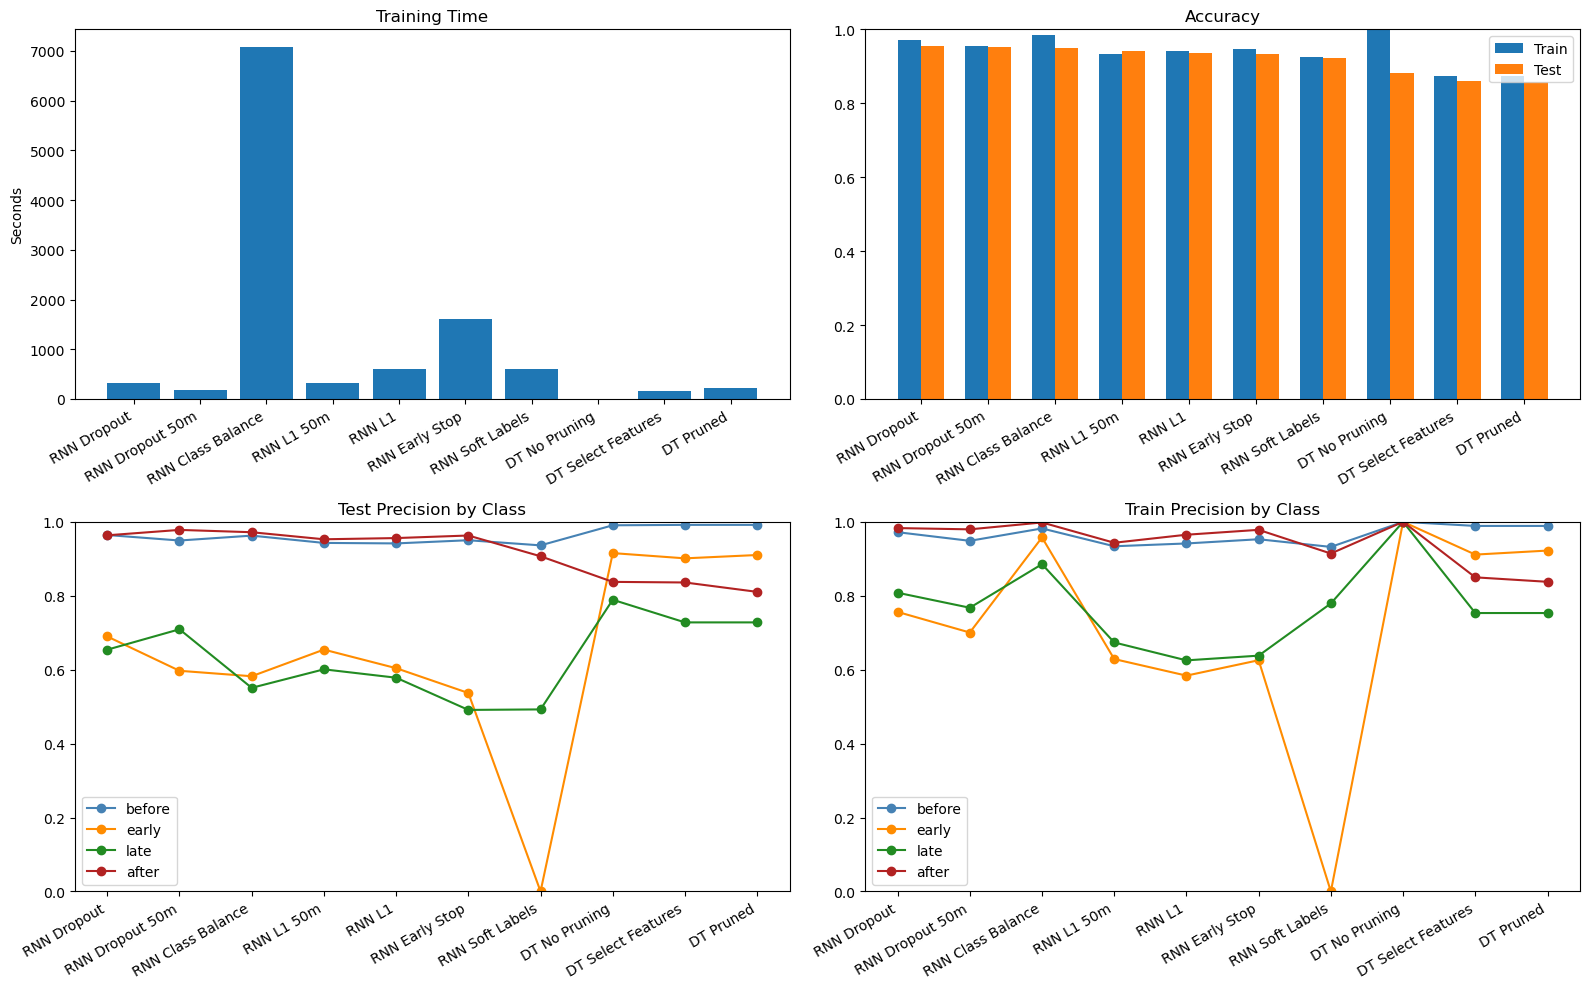

In [16]:
# ── Split data ────────────────────────────────────────────────────────────────
feature_df_edited_select = feature_df_edited.drop(columns=['ndvi_delta2', 'ndvi_delta', 'evi_delta'])
_x_tr_full, _x_te_full, _y_tr_full, _y_te_full = split_data(feature_df_edited)
_x_tr_sel,  _x_te_sel,  _y_tr_sel,  _y_te_sel  = split_data(feature_df_edited_select)

_seqs_h = build_rnn_sequences(rnn_df, use_soft_labels=False)
_norm_h  = compute_rnn_norm_stats(_seqs_h)
normalize_sequences(_seqs_h, _norm_h)
_trainval_h, _test_h = split_sequences(_seqs_h,      val_frac=0.15,  seed=42)
_train_h,    _val_h  = split_sequences(_trainval_h,  val_frac=0.176, seed=42)

if 'rnn_df_50m' in dir():
    _seqs_50m = build_rnn_sequences(rnn_df_50m, use_soft_labels=False)
    _norm_50m  = compute_rnn_norm_stats(_seqs_50m)
    normalize_sequences(_seqs_50m, _norm_50m)
    _trainval_50m, _test_50m = split_sequences(_seqs_50m, val_frac=0.15, seed=42)
    _train_50m,    _val_50m  = split_sequences(_trainval_50m, val_frac=0.176, seed=42)

# ── Collect metrics ───────────────────────────────────────────────────────────
rows = []
LABEL_ORDER = ['before', 'early', 'late', 'after']

dt_configs = [
    ('_no_pruning',      'DT No Pruning',      _x_tr_full, _y_tr_full, _x_te_full, _y_te_full),
    ('_pruned',          'DT Pruned',           _x_tr_full, _y_tr_full, _x_te_full, _y_te_full),
    ('_select_features', 'DT Select Features',  _x_tr_sel,  _y_tr_sel,  _x_te_sel,  _y_te_sel),
]
for ext, name, x_tr, y_tr, x_te, y_te in dt_configs:
    path = os.path.join(MODEL_DIR, f'decision_tree_model{ext}.joblib')
    if not os.path.exists(path):
        print(f'  Skipping {name} — file not found'); continue
    m = joblib.load(path)
    time_path = os.path.join(MODEL_DIR, f'training_time{ext}.txt')
    t = float(open(time_path).read().split()[0]) if os.path.exists(time_path) else float('nan')
    tr, te = _dt_report(m, x_tr, y_tr, x_te, y_te)
    row = {'Model': name, 'Type': 'Decision Tree', 'Training Time (s)': t,
           'Train Accuracy': tr['accuracy'], 'Test Accuracy': te['accuracy']}
    for cls in LABEL_ORDER:
        row[f'Train Prec ({cls})'] = tr[cls]['precision']
        row[f'Test Prec ({cls})']  = te[cls]['precision']
    rows.append(row)

rnn_configs = [
    ('_dropout_only',    'RNN Dropout'),
    ('_class_balancing', 'RNN Class Balance'),
    ('_early_stopping',  'RNN Early Stop'),
    ('_L1R',             'RNN L1'),
    ('_soft_labels',     'RNN Soft Labels'),
]
for ext, name in rnn_configs:
    if not os.path.exists(os.path.join(MODEL_DIR, f'rnn_model{ext}.pt')):
        print(f'  Skipping {name} — file not found'); continue
    m, _, hist = load_rnn_model(MODEL_DIR, ext)
    t = hist.get('training_time_sec', float('nan')) if hist else float('nan')
    tr = _rnn_report(m, _train_h)
    te = _rnn_report(m, _test_h)
    row = {'Model': name, 'Type': 'RNN', 'Training Time (s)': t,
           'Train Accuracy': tr['accuracy'], 'Test Accuracy': te['accuracy']}
    for cls in LABEL_ORDER:
        row[f'Train Prec ({cls})'] = tr[cls]['precision']
        row[f'Test Prec ({cls})']  = te[cls]['precision']
    rows.append(row)

if 'rnn_df_50m' in dir():
    rnn_50m_configs = [
        ('_dropout_only_50m', 'RNN Dropout 50m'),
        ('_L1R_50m',          'RNN L1 50m'),
    ]
    for ext, name in rnn_50m_configs:
        if not os.path.exists(os.path.join(MODEL_DIR, f'rnn_model{ext}.pt')):
            print(f'  Skipping {name} — file not found'); continue
        m, _, hist = load_rnn_model(MODEL_DIR, ext)
        t = hist.get('training_time_sec', float('nan')) if hist else float('nan')
        tr = _rnn_report(m, _train_50m)
        te = _rnn_report(m, _test_50m)
        row = {'Model': name, 'Type': 'RNN 50m', 'Training Time (s)': t,
               'Train Accuracy': tr['accuracy'], 'Test Accuracy': te['accuracy']}
        for cls in LABEL_ORDER:
            row[f'Train Prec ({cls})'] = tr[cls]['precision']
            row[f'Test Prec ({cls})']  = te[cls]['precision']
        rows.append(row)

df = pd.DataFrame(rows).set_index('Model')
df_sorted = df.sort_values('Test Accuracy', ascending=False)

def _fmt_time(s):
    if np.isnan(s):
        return 'N/A'
    s = int(s)
    h, rem = divmod(s, 3600)
    m, sec = divmod(rem, 60)
    return f'{h:02d}:{m:02d}:{sec:02d}'

# ── Tables ────────────────────────────────────────────────────────────────────
summary = df_sorted[['Type', 'Training Time (s)', 'Train Accuracy', 'Test Accuracy']].copy()
summary.insert(2, 'Training Time', summary['Training Time (s)'].apply(_fmt_time))
summary = summary.drop(columns='Training Time (s)')
print('=== Summary (sorted by test accuracy) ===')
print(summary.to_string(float_format='%.4f'))

print('\n=== Test Precision by Class ===')
print(df_sorted[[f'Test Prec ({c})' for c in LABEL_ORDER]]
      .rename(columns={f'Test Prec ({c})': c for c in LABEL_ORDER})
      .to_string(float_format='%.4f'))

print('\n=== Train Precision by Class ===')
print(df_sorted[[f'Train Prec ({c})' for c in LABEL_ORDER]]
      .rename(columns={f'Train Prec ({c})': c for c in LABEL_ORDER})
      .to_string(float_format='%.4f'))

# ── Figures ───────────────────────────────────────────────────────────────────
models = df_sorted.index.tolist()
x      = np.arange(len(models))
w      = 0.35
colors = ['steelblue', 'darkorange', 'forestgreen', 'firebrick']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Training time
axes[0, 0].bar(x, df_sorted['Training Time (s)'])
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=30, ha='right')
axes[0, 0].set_title('Training Time')
axes[0, 0].set_ylabel('Seconds')

# Train vs test accuracy
axes[0, 1].bar(x - w/2, df_sorted['Train Accuracy'], width=w, label='Train')
axes[0, 1].bar(x + w/2, df_sorted['Test Accuracy'],  width=w, label='Test')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=30, ha='right')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title('Accuracy')
axes[0, 1].legend()

# Test precision by class
for i, cls in enumerate(LABEL_ORDER):
    axes[1, 0].plot(models, df_sorted[f'Test Prec ({cls})'],
                    marker='o', label=cls, color=colors[i])
axes[1, 0].set_xticks(range(len(models)))
axes[1, 0].set_xticklabels(models, rotation=30, ha='right')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_title('Test Precision by Class')
axes[1, 0].legend()

# Train precision by class
for i, cls in enumerate(LABEL_ORDER):
    axes[1, 1].plot(models, df_sorted[f'Train Prec ({cls})'],
                    marker='o', label=cls, color=colors[i])
axes[1, 1].set_xticks(range(len(models)))
axes[1, 1].set_xticklabels(models, rotation=30, ha='right')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title('Train Precision by Class')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


# Conclusions

## Model Performance
These analyses were initially run using only pixels within 50 m of the Appalachian Trail for training and testing, then expanded to 100 m after model performance proved unsatisfactory.

Overall accuracy (the fraction of all observations classified correctly) is a misleading metric here because correctly identifying the transitional classes (early and late greendown) matters more than classifying the more common before and after states. The canopy spends more time in the before and after states than during active senescence (i.e., color change), so the early and late classes are inherently underrepresented in the training data. Precision(the fraction of predictions for a given class that are actually correct) for these classes is therefore a more informative metric for evaluating performance on these transitional classes.

When trained on 50 m buffer data, the recurrent neural network (RNN, a model that processes observations as a time series drawing on the history of prior observations within a season) with dropout regularization (a technique that randomly disables a subset of model connections during each training step to prevent the model from over-relying on any single feature) achieved the best overall test accuracy, but had poor precision for the early (0.60) and late (0.70) greendown classes. Adding class balancing (oversampling the underrepresented early and late training sequences so all classes are equally represented), early stopping (halting training once validation performance stops improving), or L1 regularization (adding a penalty on large model weights to favor simpler solutions) did not improve accuracy or precision for these transitional classes. Expanding training data to 100 m substantially improved model performance: the 100 m dropout-only RNN achieved the highest overall accuracy, and none of the additional regularization strategies improved upon it, though early stopping did meaningfully reduce training time at the detriment of model performance.

Among the decision trees (models that classify observations by applying a series of yes/no thresholds on input features), the unpruned full-feature model had the highest training accuracy. However, a training accuracy of 1.0 indicates severe overfitting: the model has memorized the training data rather than learned patterns that generalize to new observations and years. The feature-selected model, which also applied cost-complexity pruning to limit tree depth, achieved the best test accuracy, with a similar degree of overfitting to the pruning-only model. Removing the three lowest-importance spectral delta features slightly reduced precision for the early greendown class compared to pruning alone, but probably not enough to warrant retaining them given the additional computational cost (slower training and larger stored data tables). The unpruned full-feature model achieved the highest precision for the early and late greendown classes, but its overfitting makes it unlikely to generalize well to future years.

All decision tree variants had lower overall test accuracy than the RNN models but notably higher precision for the early and late greendown classes. Precision for these transitional classes declined in both model types when the training footprint expanded from 50 m to 100 m. This is consistent with the general observation that decision trees tend to outperform neural network models on small datasets, while the latter benefit more from additional data to learn robust temporal patterns.

For operational greendown state predictions, the feature-selected pruned decision tree and the 100 m dropout-only RNN will be used. Future improvements could include training the RNN on more pixels and incorporating higher-level spectral features such as satellite embeddings.

# Efficiency Choices
* Smoothed the Appalachian Trail geometry to reduce complexity.
* More computationally expensive steps were run locally once and their outputs stored:
    * Pulling data from Google Earth Engine, storing as processed data locally, and uploading historical average GeoTIFFs to GitHub.
    * Training models locally and then uploading them to GitHub.
* GitHub Actions pull the most recent observation values and run the prediction.